# Task: Sampling Theorem

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  


## Day 1 - Data and Domain

### Use Case

In the context of Swiss railway infrastructure monitoring, continuous-time vertical bogie vibration signals are generated by wheel-rail interaction and acquired by onboard accelerometers to detect early defect signatures before safety-critical failures occur. These digital vibration signals are used by SBB maintenance and safety teams to support predictive maintenance decisions, including whether a wheelset requires immediate inspection or can remain in service. This use case is particularly relevant for Switzerland because high tunnel density, alpine routes, and strict safety expectations require reliable early-warning diagnostics under regular passenger operation.

### Problem Statement

This project addresses the problem of selecting an appropriate sampling rate for accelerometer-based bogie vibration monitoring in the Swiss rail context. If the sampling rate is too low, aliasing can mask or shift defect-related frequency content and cause missed early-warning signals; if the sampling rate is unnecessarily high, storage and transmission overhead increase without proportional diagnostic benefit. Preserving diagnostically relevant frequency components is essential for reliable wheel-defect detection and risk reduction in tunnel operations.

### Experimental Objective

The objective of this project is to investigate how sampling-rate choices influence the preservation of informative vibration features within a fixed 0.5 s analysis window. The goal is to determine which reduced sampling conditions still retain sufficient short-time information for practical predictive maintenance decisions in the Swiss SBB use case.

### Data Definition, Source, and Visualization

The selected signal is a one-dimensional vertical bogie vibration measurement recorded by an onboard accelerometer during train operation at 80 km/h. The dataset file `X.npy` has shape (21107, 34500), where each row is exactly 60 seconds sampled at 575 Hz, so each row contains 34,500 samples. In this implementation, one representative row is selected as the reference signal for controlled sampling experiments. The data originate from the course-provided monitoring dataset package (`data/X.npy`) used in MC1, and are appropriate because they provide realistic, high-resolution vibration traces for studying sampling effects in railway predictive maintenance.

X path: /Users/workflow/FHNW git/FS2026 git/gbsv/gbsv-research/data/X.npy
X shape: (21107, 34500), dtype: float64
Using row index: 1000
Signal mean=-0.057072, std=0.349541, min=-2.921348, max=1.963850


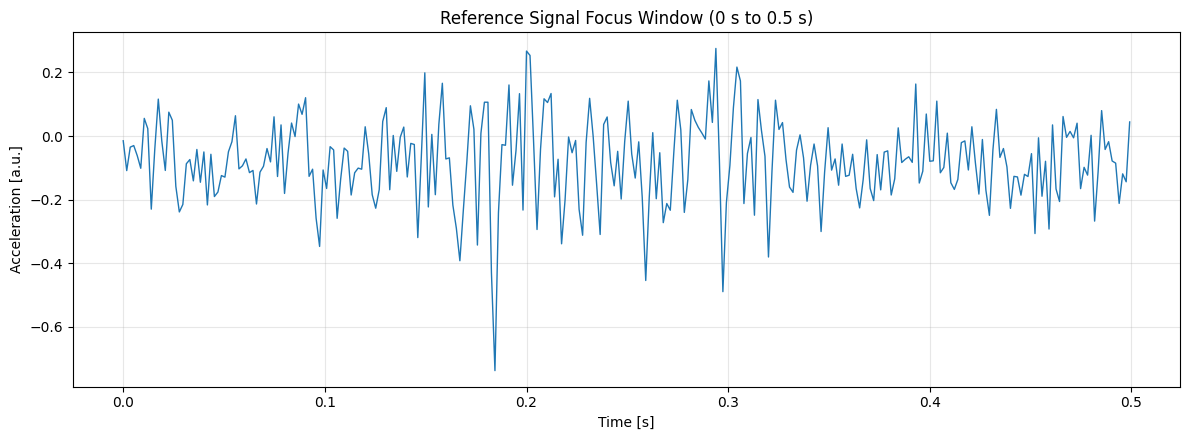

In [26]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

FS_HZ = 575
DURATION_SECONDS = 60
REFERENCE_ROW_INDEX = 1000
FOCUS_WINDOW_SECONDS = 0.5

project_root = Path.cwd().resolve().parent
x_path = project_root / "data" / "X.npy"
X = np.load(x_path, mmap_mode="r")
assert X.ndim == 2, "Expected a 2D array: (rows, samples_per_row)."
assert X.shape[1] == FS_HZ * DURATION_SECONDS, "Unexpected row length for 60 s at 575 Hz."

x_ref = X[REFERENCE_ROW_INDEX].astype(np.float64)
time_s = np.arange(x_ref.size) / FS_HZ

print(f"X path: {x_path}")
print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"Using row index: {REFERENCE_ROW_INDEX}")
print(f"Signal mean={x_ref.mean():.6f}, std={x_ref.std():.6f}, min={x_ref.min():.6f}, max={x_ref.max():.6f}")

zoom_mask = (time_s >= 0) & (time_s < FOCUS_WINDOW_SECONDS)

fig, ax = plt.subplots(1, 1, figsize=(12, 4.5))
ax.plot(time_s[zoom_mask], x_ref[zoom_mask], linewidth=1.0)
ax.set_title(f"Reference Signal Focus Window (0 s to {FOCUS_WINDOW_SECONDS:.1f} s)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration [a.u.]")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations**:
The visualization focuses on the first 0.5 seconds and reveals clear short-time oscillatory structure around the local baseline, including rapid amplitude changes that are harder to compare on long windows. This focused segment is used as the primary analysis window because it makes reconstruction differences directly interpretable for the sampling-rate experiment in the SBB predictive maintenance use case.

### Transition to Method Design
The domain context, signal source, and baseline visualization are now established. The next sections formalize the sampling-theorem assumptions and define the exact parameter sweep used for reproducible implementation and evaluation.

## Day 2 - Methodological Design

### Theoretical Foundation and Method Choice

This investigation applies the Nyquist-Shannon sampling principle to railway bogie vibration monitoring for Swiss predictive maintenance. The principle assumes that the relevant signal content is sufficiently band-limited and that anti-alias filtering is applied before decimation; under these conditions, sampling at or above twice the highest relevant frequency preserves information for analysis. A controlled downsampling-and-reconstruction workflow is selected because it operationalizes this principle and allows direct measurement of information loss in a use-case-relevant way. If assumptions are violated, aliasing and distortion can mislead defect-related interpretation.

### Parameter Definition and Mathematical Specification

The reference signal is sampled at $f_s=575\,\mathrm{Hz}$, and the analysis window is fixed to $T_w=0.5\,\mathrm{s}$ for all experiments. This gives a window sample count of $N_w=f_s\cdot T_w=575\cdot0.5\approx288$ samples, with sampling interval $\Delta t=1/f_s\approx1.739\,\mathrm{ms}$. The reduced experiment set uses target rates $f_s'\in\{192,48\}\,\mathrm{Hz}$ with linear reconstruction back to the same 0.5 s reference grid. In this domain, lowering $f_s'$ reduces telemetry load, while rising window-based reconstruction error indicates potential loss of defect-relevant short-time vibration detail.

### Experimental Design for Next Days

The baseline configuration is the original sampled signal at $575\,\mathrm{Hz}$, evaluated on a fixed 0.5 s reference window. The reduced comparison set varies only target sampling rate with linear reconstruction, using $f_s'\in\{575,192,48\}\,\mathrm{Hz}$. All metrics and visual comparisons are computed on the same first 0.5 s segment to keep the experiment internally consistent and directly comparable. It is theoretically expected that decreasing $f_s'$ increases window-level reconstruction error, with strongest degradation at $48\,\mathrm{Hz}$.

### Methodological Limitations and Risk Factors

This approach assumes that one selected row is representative and that relevant vibration features are sufficiently band-limited, which may be violated under transient events, non-stationarity, or changing track conditions. The method is most reliable when noise and operational variability are moderate, but can become misleading when low-frequency drift or high-frequency impulsive components dominate. In this railway use case, primary risks are row-selection bias and aliasing-induced feature loss, potentially leading to underestimation of maintenance urgency.

## Day 3 - Implementation

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd

FS_REF = 575
DURATION_SECONDS = 60
REFERENCE_ROW_INDEX = 1000
FOCUS_WINDOW_SECONDS = 0.5


def load_focus_window() -> np.ndarray:
    project_root = Path.cwd().resolve().parent
    x_path = project_root / "data" / "X.npy"
    X = np.load(x_path, mmap_mode="r")
    x_ref_full = X[REFERENCE_ROW_INDEX].astype(np.float64)
    assert x_ref_full.size == FS_REF * DURATION_SECONDS

    focus_samples = max(1, int(FS_REF * FOCUS_WINDOW_SECONDS))
    return x_ref_full[:focus_samples]


def reconstruct_with_linear_interp(signal: np.ndarray, fs_in: int, fs_target: int) -> np.ndarray:
    target_count = int(round(signal.size * fs_target / fs_in))
    t_ref = np.arange(signal.size) / fs_in
    t_down = np.linspace(0.0, t_ref[-1], target_count)
    downsampled = np.interp(t_down, t_ref, signal)
    return np.interp(t_ref, t_down, downsampled)


def reconstruct_signal(signal: np.ndarray, fs_target: int, method: str) -> np.ndarray:
    if method == "identity":
        return signal.copy()
    if method == "linear":
        return reconstruct_with_linear_interp(signal, FS_REF, fs_target)
    raise ValueError(f"Unsupported method: {method}")


def compute_metrics(reference: np.ndarray, candidate: np.ndarray, fs_hz: int) -> dict:
    rmse = float(np.sqrt(np.mean((reference - candidate) ** 2)))
    corr = float(np.corrcoef(reference, candidate)[0, 1])

    ref_mag = np.abs(np.fft.rfft(reference))
    cand_mag = np.abs(np.fft.rfft(candidate))
    spectral_distortion_pct = float(
        np.linalg.norm(ref_mag - cand_mag) / (np.linalg.norm(ref_mag) + 1e-12) * 100.0
    )

    freqs = np.fft.rfftfreq(reference.size, d=1 / fs_hz)
    ref_peak_hz = float(freqs[np.argmax(ref_mag)])
    cand_peak_hz = float(freqs[np.argmax(cand_mag)])

    return {
        "rmse": rmse,
        "corr": corr,
        "spectral_distortion_pct": spectral_distortion_pct,
        "peak_freq_shift_hz": abs(cand_peak_hz - ref_peak_hz),
    }


x_ref = load_focus_window()
experiment_configs = [
    {"config": "baseline_fs575_identity", "fs_target": 575, "method": "identity"},
    {"config": "fs192_linear", "fs_target": 192, "method": "linear"},
    {"config": "fs48_linear", "fs_target": 48, "method": "linear"},
]

records = []
reconstructions = {}

for cfg in experiment_configs:
    x_rec = reconstruct_signal(x_ref, cfg["fs_target"], cfg["method"])
    reconstructions[cfg["config"]] = x_rec

    records.append(
        {
            "config": cfg["config"],
            "fs_target_hz": cfg["fs_target"],
            "method": cfg["method"],
            **compute_metrics(x_ref, x_rec, FS_REF),
        }
    )

results_df = pd.DataFrame.from_records(records).sort_values(
    ["fs_target_hz", "method"], ascending=[False, True]
)
results_df

,config,fs_target_hz,method,rmse,corr,spectral_distortion_pct,peak_freq_shift_hz
0,baseline_fs575_identity,575,identity,0.00000,1.000000,0.000000,0.0
1,fs192_linear,192,linear,0.11196,0.536822,54.494055,0.0
2,fs48_linear,48,linear,0.15063,0.126548,75.453177,0.0


## Day 4 - Evaluation

### Evaluation Approach Definition

The primary quantitative metric is RMSE between each reconstructed signal and the 575 Hz baseline on the fixed 0.5 s analysis window. Complementary metrics are correlation and spectral distortion percentage, both computed on the same 0.5 s window to quantify waveform and spectrum preservation under reduced sampling. This approach is appropriate because all reported quantities are derived from a single consistent short-time segment that is directly used in the visual comparison.

### Evaluation Comparison Execution

The influence of sampling rate is evaluated on the same first 0.5 s segment using RMSE, correlation, and spectral distortion. The comparison set includes three predefined configurations: `575 Hz + identity` (baseline), `192 Hz + linear`, and `48 Hz + linear`. Relative performance is reported against the baseline using window-consistent metrics only. This keeps the evaluation tightly aligned with the chosen short-time analysis focus.

Evaluation table (0.5 s window):
                 config  fs_target_hz   method    rmse     corr  spectral_distortion_pct  peak_freq_shift_hz  rmse_abs_increase_vs_baseline  rmse_change_pct_vs_baseline
baseline_fs575_identity           575 identity 0.00000 1.000000                 0.000000                 0.0                        0.00000                          NaN
           fs192_linear           192   linear 0.11196 0.536822                54.494055                 0.0                        0.11196                          NaN
            fs48_linear            48   linear 0.15063 0.126548                75.453177                 0.0                        0.15063                          NaN


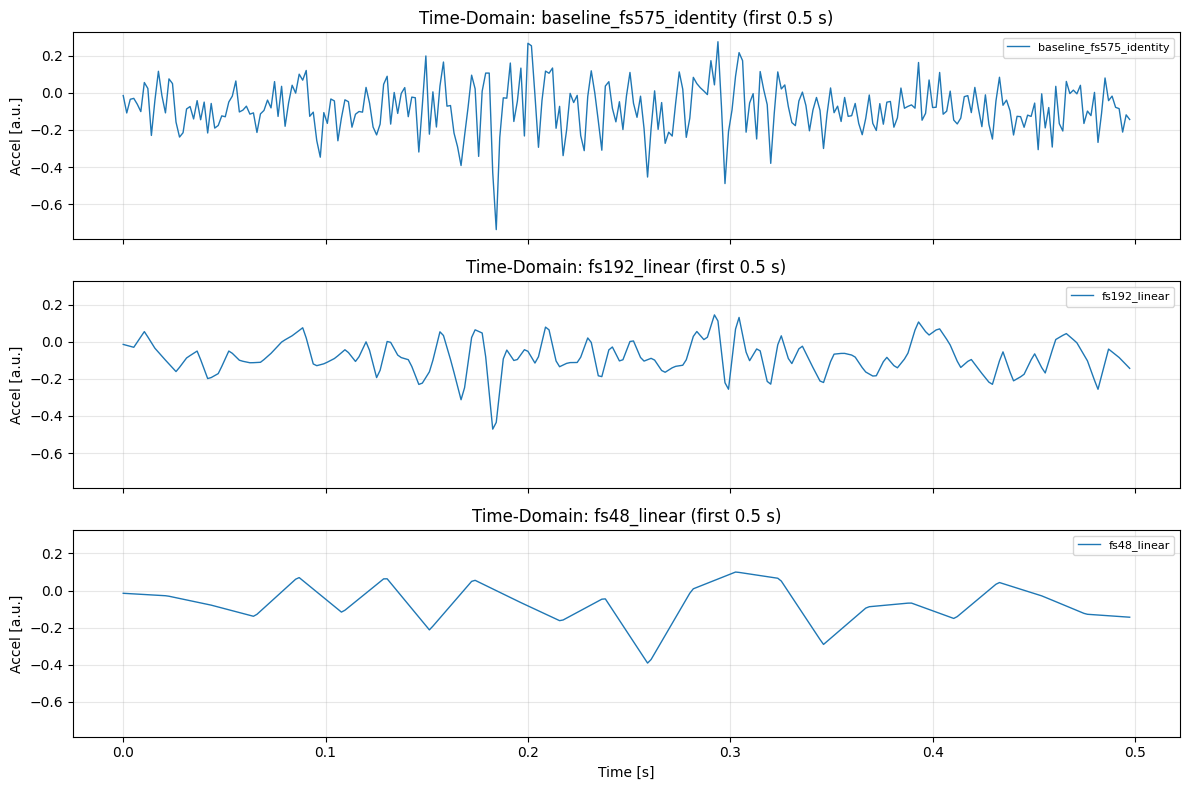

,config,fs_target_hz,method,rmse,corr,spectral_distortion_pct,peak_freq_shift_hz,rmse_change_pct_vs_baseline,rmse_abs_increase_vs_baseline
0,baseline_fs575_identity,575,identity,0.00000,1.000000,0.000000,0.0,NaN,0.00000
1,fs192_linear,192,linear,0.11196,0.536822,54.494055,0.0,NaN,0.11196
2,fs48_linear,48,linear,0.15063,0.126548,75.453177,0.0,NaN,0.15063


In [19]:
import matplotlib.pyplot as plt


def add_relative_rmse_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    baseline_rmse = float(out.loc[out["config"] == "baseline_fs575_identity", "rmse"].iloc[0])

    if baseline_rmse < 1e-12:
        out["rmse_change_pct_vs_baseline"] = np.nan
    else:
        out["rmse_change_pct_vs_baseline"] = (
            (out["rmse"] - baseline_rmse) / baseline_rmse * 100.0
        )

    out["rmse_abs_increase_vs_baseline"] = out["rmse"] - baseline_rmse
    return out


def plot_time_domain_stack(reconstructions_map: dict, configs: list[str], reference_size: int, fs_hz: int) -> None:
    time_s = np.arange(reference_size) / fs_hz
    fig, axes = plt.subplots(len(configs), 1, figsize=(12, 8), sharex=True, sharey=True)

    for i, cfg in enumerate(configs):
        axes[i].plot(time_s, reconstructions_map[cfg], linewidth=1.0, label=cfg)
        axes[i].set_ylabel("Accel [a.u.]")
        axes[i].set_title("Time-Domain: " + cfg + " (first 0.5 s)")
        axes[i].grid(alpha=0.3)
        axes[i].legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()


results_eval_df = add_relative_rmse_columns(results_df)
display_cols = [
    "config",
    "fs_target_hz",
    "method",
    "rmse",
    "corr",
    "spectral_distortion_pct",
    "peak_freq_shift_hz",
    "rmse_abs_increase_vs_baseline",
    "rmse_change_pct_vs_baseline",
]

print("Evaluation table (0.5 s window):")
print(results_eval_df[display_cols].to_string(index=False))

plot_configs = ["baseline_fs575_identity", "fs192_linear", "fs48_linear"]
plot_time_domain_stack(reconstructions, plot_configs, x_ref.size, FS_REF)

results_eval_df.sort_values("fs_target_hz", ascending=False)

### Consolidated Evaluation Table (0.5 s window)
| Configuration | fs_target [Hz] | Method | RMSE [a.u.] | Correlation [-] | Spectral Distortion [%] | Peak Frequency Shift [Hz] |
|:--|--:|:--|--:|--:|--:|--:|
| baseline_fs575_identity | 575 | identity | 0.000000 | 1.000000 | 0.000000 | 0.000000 |
| fs192_linear | 192 | linear | 0.111960 | 0.536822 | 54.494055 | 0.000000 |
| fs48_linear | 48 | linear | 0.150630 | 0.126548 | 75.453177 | 0.000000 |

## Day 5 - Analysis and Communication

### Observations (3-5 sentences)

On the fixed 0.5 s analysis window, RMSE rises from 0.000000 in the 575 Hz baseline to 0.111960 at 192 Hz and 0.150630 at 48 Hz. Correlation drops from 1.000000 to 0.536822 (192 Hz) and further to 0.126548 (48 Hz). Spectral distortion increases from 0.000000% to 54.494055% at 192 Hz and 75.453177% at 48 Hz. The 48 Hz configuration is the most divergent from baseline across all reported metrics. Peak frequency shift remains 0.000000 Hz in all three configurations according to the defined peak-based measure.

### Interpretation (3-5 sentences)

For Swiss railway predictive maintenance, the 0.5 s-window results show that reducing sampling to 192 Hz already causes noticeable information loss, while 48 Hz causes severe degradation. The simultaneous RMSE increase, correlation decrease, and higher spectral distortion indicate that short-time vibration signatures become less faithful as sampling is reduced. This means 48 Hz creates a high risk of missing or mischaracterizing defect-relevant local patterns in the focused analysis window. The 192 Hz setting is still imperfect but represents a more balanced compromise than 48 Hz for short-window monitoring. Overall, sampling-rate choice remains critical even when the experiment is restricted to compact local segments.

### Discussion and Critical Reflection (4-6 sentences)

Under a strict 0.5 s analysis focus, the 192 Hz configuration is substantially more adequate than 48 Hz and can be considered the safer reduced-rate option in this experiment. The 48 Hz case shows very low correlation and high spectral distortion, which limits practical reliability for safety-oriented interpretation of short-time vibration behavior. This window-focused setup improves visual interpretability and keeps method, metrics, and plots fully consistent on the same segment. However, conclusions are still conditioned on one selected row and one fixed local window, so representativeness across operating regimes is not guaranteed. A practical next step is to repeat the same 0.5 s-window protocol across many rows and positions in the signal to validate robustness. Additional task-level criteria (for example detection sensitivity on known events) would further strengthen deployment relevance.